# Legal Hallucination Study — Deep Analytics

Analysing hallucination rates across:
- **Task** (11 tasks)
- **Model** (Llama-3.3-70B, GPT-4o-mini, Gemini-2.5-flash)
- **Condition** (Baseline, Structured, Premise)
- **Court level** (SCOTUS, Circuit Court, District Court)
- **Circuit** (court_slug 1–13)
- **Case source** (songer, cap, fake, scdb, overruled_db)
- **Correctness score distribution** (not just binary)
- **Latency**
- **Task complexity groupings**
- **Refusal / abstain behaviour**
- **Year era** (joined from dataset.csv)

HERE: I THINK fake preise should be treated separaetley 

In [1]:
import json, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.1f}'.format)
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'baseline': '#6C7A89', 'structured': '#2980B9', 'premise': '#27AE60'}
MODEL_LABELS = {'groq': 'Llama-3.3-70B', 'gpt4omini': 'GPT-4o-mini', 'gemini': 'Gemini-2.5-flash'}
TASK_ORDER = [
    'case_existence', 'fake_case_existence', 'court_id', 'citation_retrieval',
    'cited_precedent', 'majority_author', 'affirm_reverse', 'quotation',
    'year_overruled', 'fake_year_overruled', 'fake_dissent'
]

In [2]:
# ── Load all scored JSONL files ──────────────────────────────────────────────
records = []
for path in glob.glob('results/scores/*.jsonl'):
    with open(path) as f:
        for line in f:
            records.append(json.loads(line))

df = pd.DataFrame(records)
df['model_label'] = df['model_key'].map(MODEL_LABELS)
df['hallucination'] = df['hallucination'].astype(bool)
df['correctness_score'] = pd.to_numeric(df['correctness_score'], errors='coerce')
df['latency_s'] = pd.to_numeric(df['latency_s'], errors='coerce')
df['court_level'] = df['court_level'].str.strip()
df['court_slug'] = pd.to_numeric(df['court_slug'], errors='coerce')

# ── Join with dataset.csv for year + case_source ──────────────────────────────
meta = pd.read_csv('dataset.csv', low_memory=False)
meta = meta[meta['id'].apply(lambda x: str(x).isdigit())].copy()
meta['id'] = meta['id'].astype(int)
meta['year'] = pd.to_numeric(meta['year'], errors='coerce')
meta['case_source'] = meta['case_source'].astype(str)

df['row_id_int'] = pd.to_numeric(df['row_id'], errors='coerce')
df = df.merge(meta[['id','year','case_source']].drop_duplicates('id'),
              left_on='row_id_int', right_on='id', how='left')

# Task complexity grouping
COMPLEXITY = {
    'case_existence': 'Factual lookup',
    'fake_case_existence': 'Fake-case detection',
    'court_id': 'Factual lookup',
    'citation_retrieval': 'Precise recall',
    'cited_precedent': 'Precise recall',
    'majority_author': 'Factual lookup',
    'affirm_reverse': 'Reasoning',
    'quotation': 'Precise recall',
    'year_overruled': 'Temporal lookup',
    'fake_year_overruled': 'Fake-case detection',
    'fake_dissent': 'Fake-case detection',
}
df['complexity'] = df['task'].map(COMPLEXITY)

COURT_LABELS = {'scotus': 'SCOTUS', 'coa': 'Circuit Court', 'usdc': 'District Court'}
df['court_label'] = df['court_level'].map(COURT_LABELS).fillna(df['court_level'])

print(f"Total records: {len(df):,}")
print(df.groupby(['model_key','condition'])['hallucination'].count().unstack())

Total records: 33,135
condition  baseline  premise  structured
model_key                               
gemini         4480     1499        2156
gpt4omini      5500     1500        5500
groq           5500     1500        5500


## 1. Hallucination Rate: Task × Model × Condition

In [3]:
pivot = (
    df.groupby(['task','model_label','condition'])['hallucination']
    .mean().mul(100).unstack('condition').round(1)
)
pivot = pivot.reindex(TASK_ORDER, level='task')
print(pivot.to_string())

condition                             baseline  premise  structured
task                model_label                                    
case_existence      GPT-4o-mini           19.6      NaN        12.2
                    Gemini-2.5-flash       4.1      NaN         5.4
                    Llama-3.3-70B          8.6      NaN         7.0
fake_case_existence GPT-4o-mini           24.0      6.6         6.6
                    Gemini-2.5-flash      99.0     99.6         NaN
                    Llama-3.3-70B         83.0     54.4        51.6
court_id            GPT-4o-mini           45.4      NaN        45.6
                    Gemini-2.5-flash      46.9      NaN        47.8
                    Llama-3.3-70B         36.8      NaN        55.6
citation_retrieval  GPT-4o-mini           87.4      NaN        86.0
                    Gemini-2.5-flash      63.2      NaN        61.8
                    Llama-3.3-70B         84.6      NaN        84.0
cited_precedent     GPT-4o-mini           99.4  

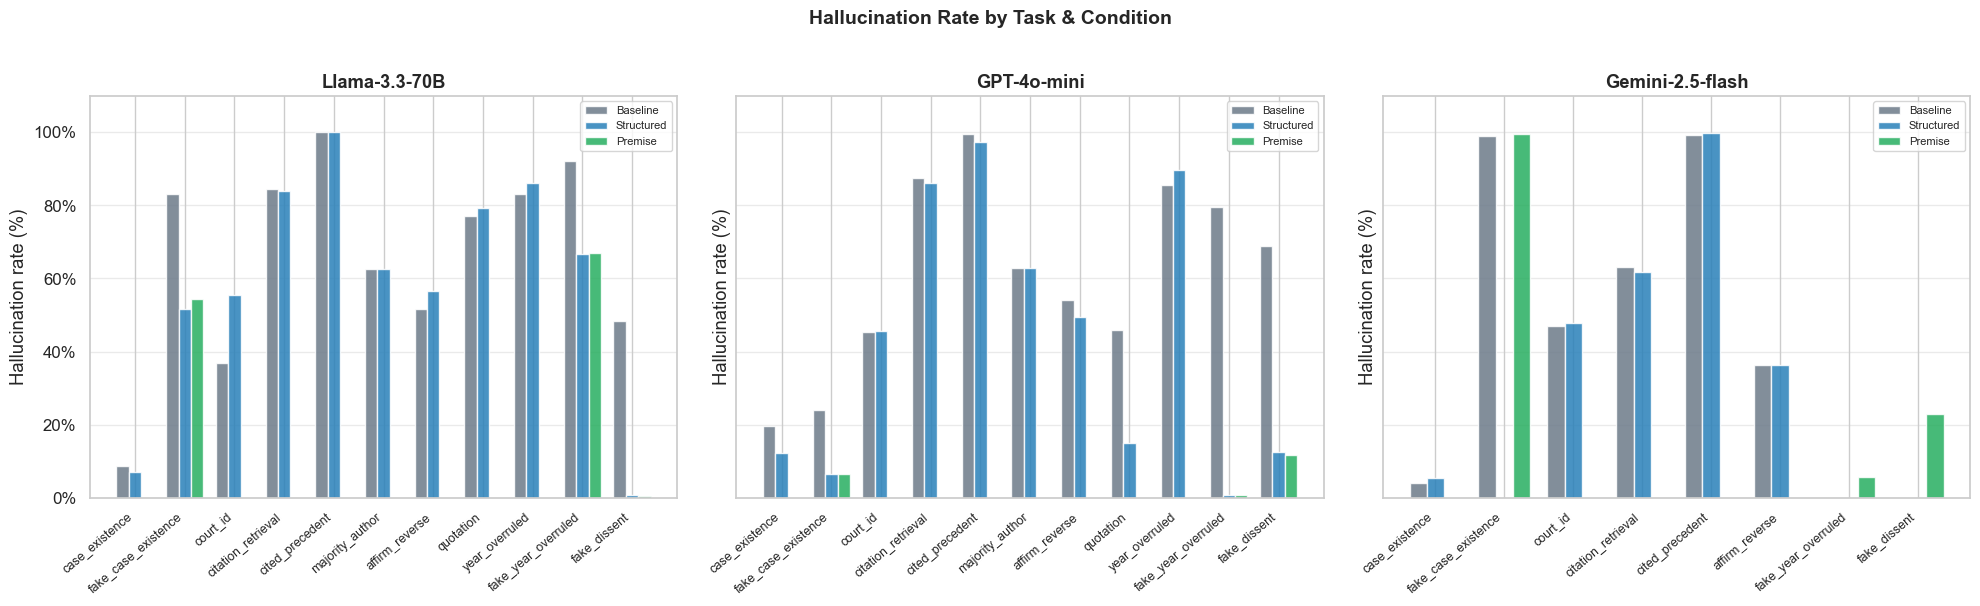

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
models = ['Llama-3.3-70B', 'GPT-4o-mini', 'Gemini-2.5-flash']

for ax, model in zip(axes, models):
    sub = df[df['model_label'] == model]
    g = sub.groupby(['task','condition'])['hallucination'].mean().mul(100).unstack('condition')
    g = g.reindex([t for t in TASK_ORDER if t in g.index])
    conditions = [c for c in ['baseline','structured','premise'] if c in g.columns]
    x = np.arange(len(g))
    width = 0.25
    for i, cond in enumerate(conditions):
        ax.bar(x + i*width, g[cond], width, label=cond.title(),
               color=PALETTE[cond], alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(g.index, rotation=40, ha='right', fontsize=9)
    ax.set_title(model, fontweight='bold')
    ax.set_ylabel('Hallucination rate (%)')
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Hallucination Rate by Task & Condition', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/fig_task_condition.png', dpi=150, bbox_inches='tight')
plt.show()

HERE: fix that i have NaNs for wuite a few — and why dont I see any approval? 

## 2. Delta Heatmap: Structured vs Baseline (improvement per task × model)

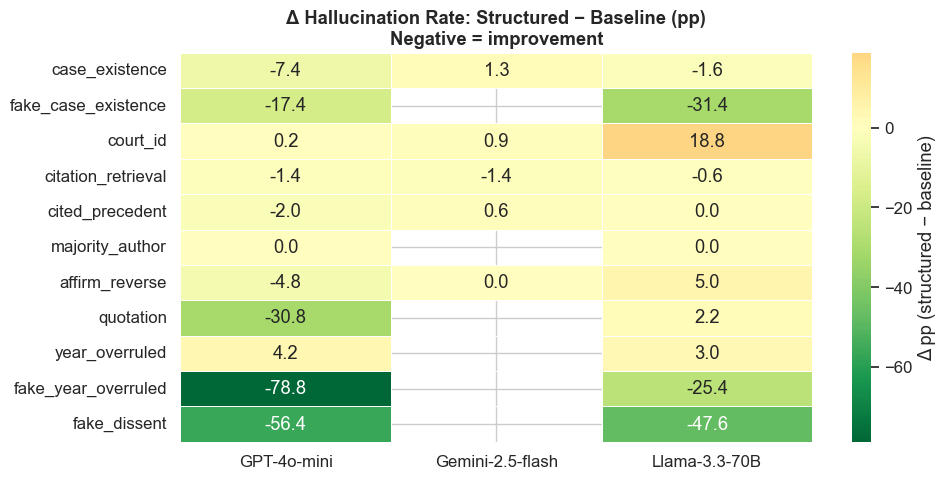


Most improved task per model:
model_label
GPT-4o-mini         fake_year_overruled
Gemini-2.5-flash     citation_retrieval
Llama-3.3-70B              fake_dissent
dtype: str

Most harmed task per model:
model_label
GPT-4o-mini         year_overruled
Gemini-2.5-flash    case_existence
Llama-3.3-70B             court_id
dtype: str


In [5]:
rates = df.groupby(['task','model_label','condition'])['hallucination'].mean().mul(100)
base = rates.xs('baseline', level='condition').unstack('model_label')
struct = rates.xs('structured', level='condition').unstack('model_label')
delta = (struct - base).reindex([t for t in TASK_ORDER if t in base.index])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(delta, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Δ pp (structured − baseline)'})
ax.set_title('Δ Hallucination Rate: Structured − Baseline (pp)\nNegative = improvement', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('results/fig_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nMost improved task per model:')
print(delta.idxmin())
print('\nMost harmed task per model:')
print(delta.idxmax())

## 3. Court Level Analysis

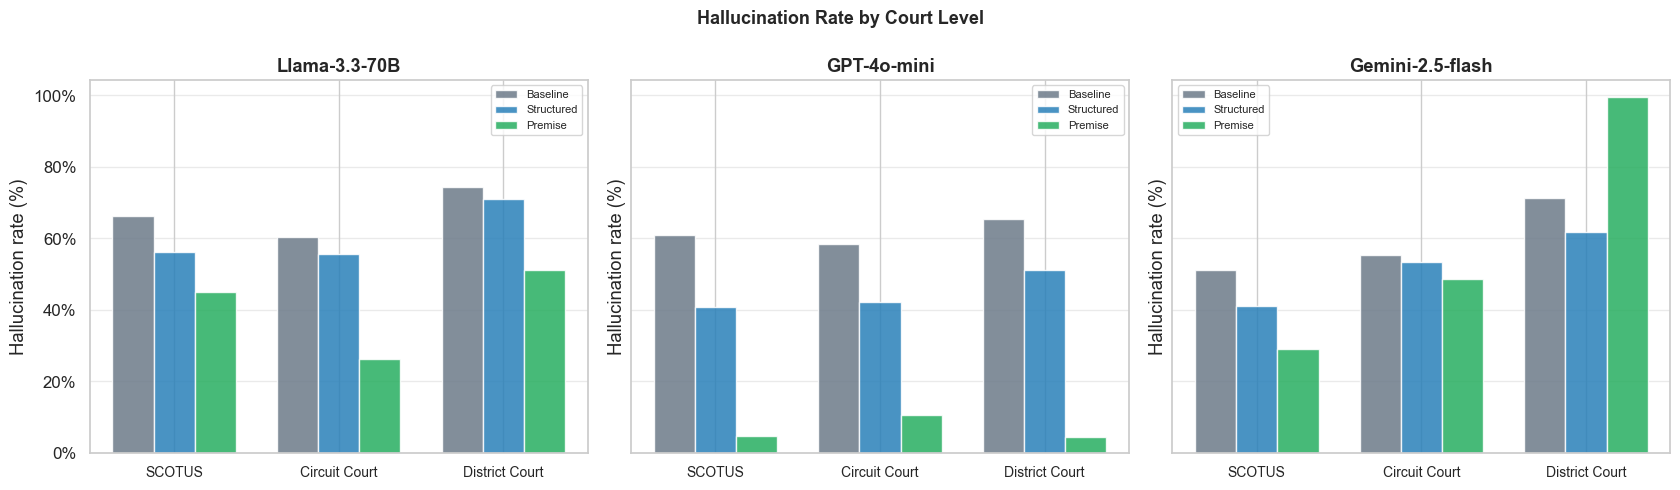

condition       baseline  premise  structured
court_label                                  
Circuit Court       58.0     28.5        49.8
District Court      70.4     51.7        61.3
SCOTUS              60.7     26.3        47.6


In [6]:
court_df = df[df['court_label'].isin(['SCOTUS','Circuit Court','District Court'])]
court_rates = (
    court_df.groupby(['court_label','model_label','condition'])['hallucination']
    .mean().mul(100).reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
court_order = ['SCOTUS', 'Circuit Court', 'District Court']

for ax, model in zip(axes, models):
    sub = court_rates[court_rates['model_label'] == model]
    pivot = sub.pivot(index='court_label', columns='condition', values='hallucination')
    pivot = pivot.reindex(court_order)
    conds = [c for c in ['baseline','structured','premise'] if c in pivot.columns]
    x = np.arange(len(pivot))
    for i, cond in enumerate(conds):
        ax.bar(x + i*0.25, pivot[cond], 0.25, label=cond.title(),
               color=PALETTE[cond], alpha=0.85)
    ax.set_xticks(x + 0.25)
    ax.set_xticklabels(pivot.index, fontsize=10)
    ax.set_title(model, fontweight='bold')
    ax.set_ylabel('Hallucination rate (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Hallucination Rate by Court Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/fig_court_level.png', dpi=150, bbox_inches='tight')
plt.show()

# Raw table
print(court_df.groupby(['court_label','condition'])['hallucination'].mean().mul(100).unstack().round(1))

## 4. Circuit-Level Analysis (court_slug 1–13 = Federal Circuit Courts)

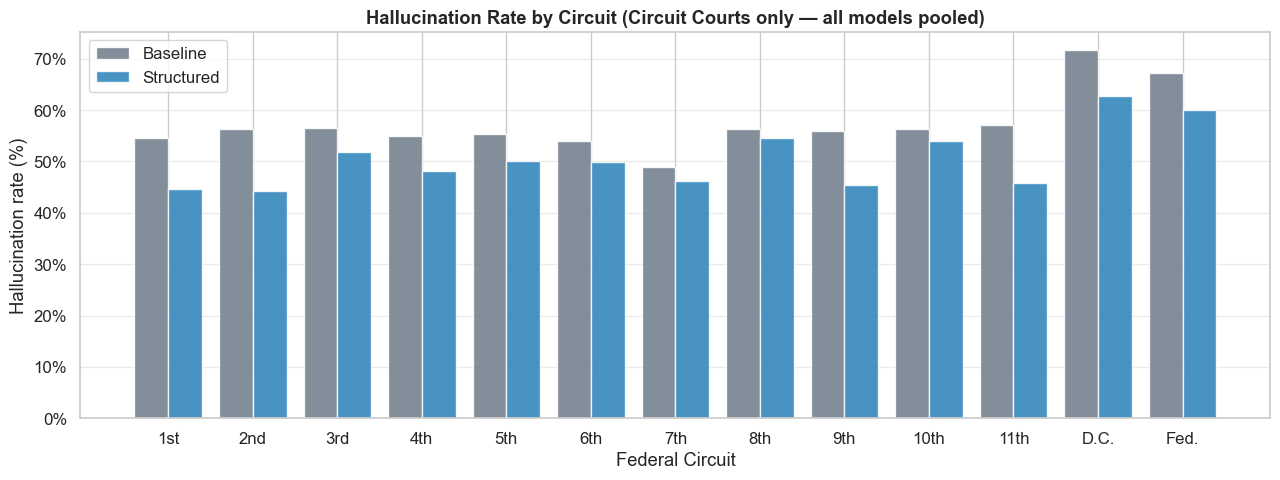

Circuit hallucination rates (baseline vs structured):
         Baseline  Structured  Delta
circuit                             
1st          54.5        44.6   -9.9
2nd          56.2        44.2  -12.0
3rd          56.6        51.8   -4.8
4th          55.0        48.1   -6.9
5th          55.3        50.2   -5.1
6th          53.9        49.9   -4.0
7th          48.9        46.2   -2.7
8th          56.2        54.6   -1.6
9th          55.9        45.4  -10.5
10th         56.2        54.0   -2.2
11th         57.1        45.8  -11.4
D.C.         71.6        62.8   -8.9
Fed.         67.2        60.1   -7.1


In [7]:
CIRCUIT_NAMES = {
    1: '1st', 2: '2nd', 3: '3rd', 4: '4th', 5: '5th',
    6: '6th', 7: '7th', 8: '8th', 9: '9th', 10: '10th',
    11: '11th', 12: 'D.C.', 13: 'Fed.'
}

coa = df[(df['court_level'] == 'coa') & df['court_slug'].notna()].copy()
coa['circuit'] = coa['court_slug'].astype(int).map(CIRCUIT_NAMES)

circ_baseline = (
    coa[coa['condition'] == 'baseline']
    .groupby('circuit')['hallucination'].mean().mul(100)
    .reindex([CIRCUIT_NAMES[i] for i in range(1,14)])
)

circ_struct = (
    coa[coa['condition'] == 'structured']
    .groupby('circuit')['hallucination'].mean().mul(100)
    .reindex([CIRCUIT_NAMES[i] for i in range(1,14)])
)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(circ_baseline))
ax.bar(x - 0.2, circ_baseline, 0.4, label='Baseline', color=PALETTE['baseline'], alpha=0.85)
ax.bar(x + 0.2, circ_struct, 0.4, label='Structured', color=PALETTE['structured'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(circ_baseline.index)
ax.set_xlabel('Federal Circuit')
ax.set_ylabel('Hallucination rate (%)')
ax.set_title('Hallucination Rate by Circuit (Circuit Courts only — all models pooled)', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('results/fig_circuit.png', dpi=150, bbox_inches='tight')
plt.show()

print('Circuit hallucination rates (baseline vs structured):')
print(pd.DataFrame({'Baseline': circ_baseline, 'Structured': circ_struct, 'Delta': circ_struct - circ_baseline}).round(1))

## 5. Case Source Analysis

Hallucination rate by case source:
condition     baseline  premise  structured
case_source                                
cap               63.3      8.3        57.5
fake              66.8     53.5        29.1
overruled_db      84.4      NaN        88.0
scdb              57.4     21.5        41.4
songer            49.8      NaN        51.8


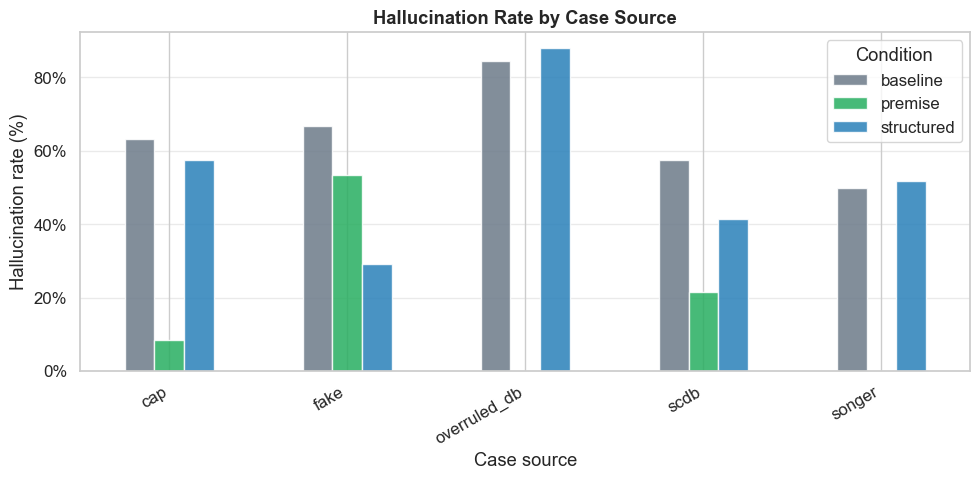

In [8]:
src = df[df['case_source'].notna() & (df['case_source'] != 'nan')]
src_rates = (
    src.groupby(['case_source','condition'])['hallucination']
    .agg(['mean','count']).reset_index()
)
src_rates['mean'] = src_rates['mean'] * 100

src_pivot = src_rates.pivot(index='case_source', columns='condition', values='mean').round(1)
print('Hallucination rate by case source:')
print(src_pivot)

fig, ax = plt.subplots(figsize=(10, 5))
src_pivot.plot(kind='bar', ax=ax, color=[PALETTE.get(c,'gray') for c in src_pivot.columns],
               alpha=0.85, edgecolor='white')
ax.set_xlabel('Case source')
ax.set_ylabel('Hallucination rate (%)')
ax.set_title('Hallucination Rate by Case Source', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Condition')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('results/fig_case_source.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Task Complexity Groupings

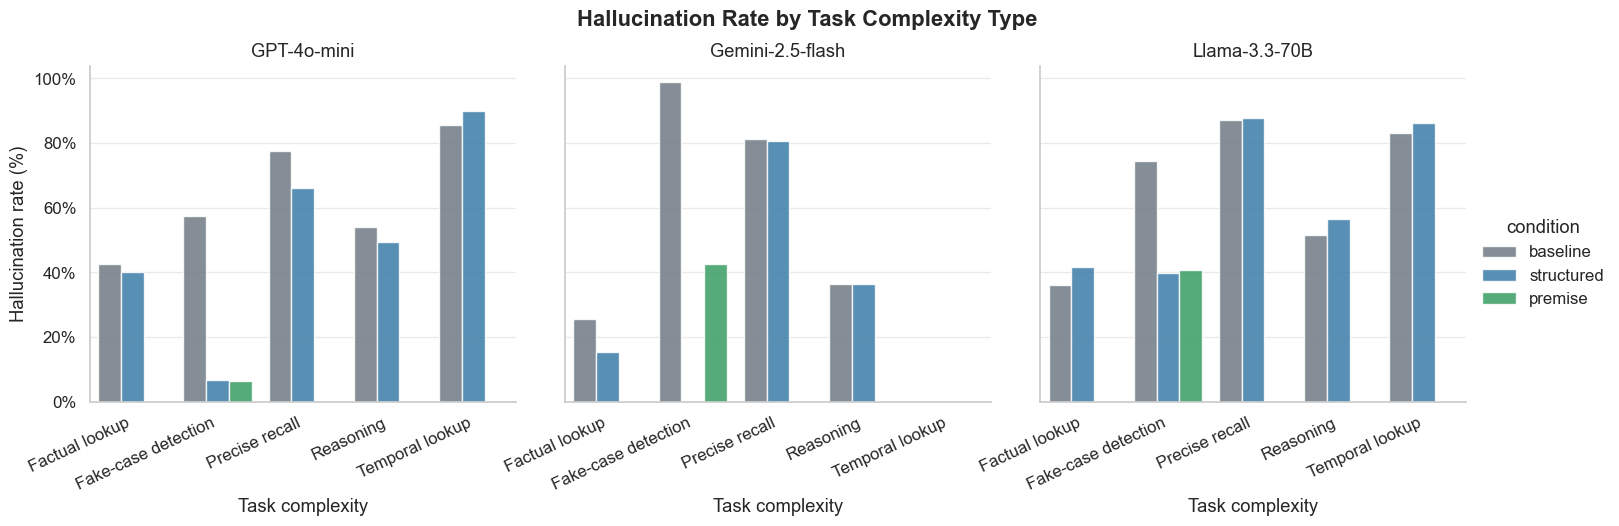

model_label                     GPT-4o-mini  Gemini-2.5-flash  Llama-3.3-70B
complexity          condition                                               
Factual lookup      baseline           42.6              25.7           36.0
                    structured         40.2              15.5           41.7
Fake-case detection baseline           57.5              99.0           74.5
                    premise             6.3              42.7           40.7
                    structured          6.6               NaN           39.7
Precise recall      baseline           77.5              81.2           87.2
                    structured         66.1              80.8           87.7
Reasoning           baseline           54.2              36.4           51.6
                    structured         49.4              36.4           56.6
Temporal lookup     baseline           85.6               NaN           83.2
                    structured         89.8               NaN           86.2

In [9]:
comp_rates = (
    df.groupby(['complexity','model_label','condition'])['hallucination']
    .mean().mul(100).reset_index()
)

g = sns.catplot(
    data=comp_rates, kind='bar',
    x='complexity', y='hallucination', hue='condition',
    col='model_label', palette=PALETTE,
    height=4.5, aspect=1.1, alpha=0.85
)
g.set_axis_labels('Task complexity', 'Hallucination rate (%)')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    for label in ax.get_xticklabels():
        label.set_rotation(25)
        label.set_ha('right')
    ax.grid(axis='y', alpha=0.4)
g.fig.suptitle('Hallucination Rate by Task Complexity Type', fontweight='bold', y=1.03)
g.fig.savefig('results/fig_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

print(comp_rates.pivot_table('hallucination', index=['complexity','condition'], columns='model_label').round(1))

## 7. Correctness Score Distribution (not just binary)

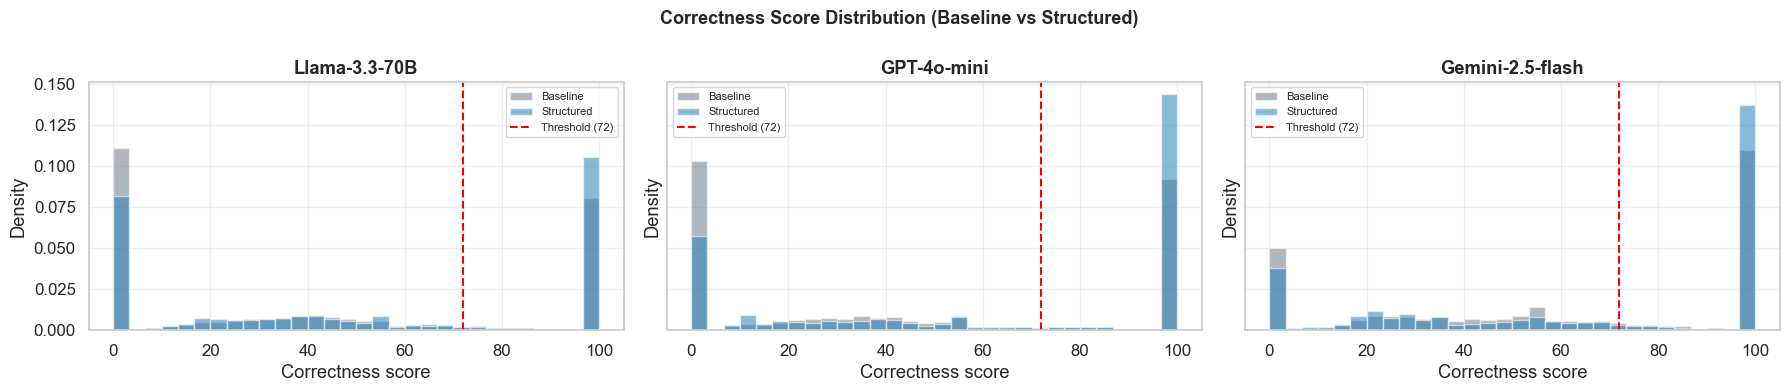

Mean correctness score (excl. refusals):
condition         baseline  premise  structured
model_label                                    
GPT-4o-mini           44.6     93.6        60.7
Gemini-2.5-flash      57.9     57.2        63.2
Llama-3.3-70B         42.0     59.3        50.5


In [10]:
valid = df[df['correctness_score'].notna() & (df['correctness_score'] != -99)]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True, sharex=True)
for ax, model in zip(axes, models):
    sub = valid[valid['model_label'] == model]
    for cond in ['baseline','structured']:
        c = sub[sub['condition'] == cond]['correctness_score']
        if len(c):
            ax.hist(c, bins=30, alpha=0.55, label=cond.title(), color=PALETTE[cond], density=True)
    ax.axvline(72, color='red', linestyle='--', linewidth=1.5, label='Threshold (72)')
    ax.set_title(model, fontweight='bold')
    ax.set_xlabel('Correctness score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Correctness Score Distribution (Baseline vs Structured)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/fig_score_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Mean score per model × condition
print('Mean correctness score (excl. refusals):')
print(valid.groupby(['model_label','condition'])['correctness_score'].mean().unstack().round(1))

## 8. Refusal / Abstention Rate

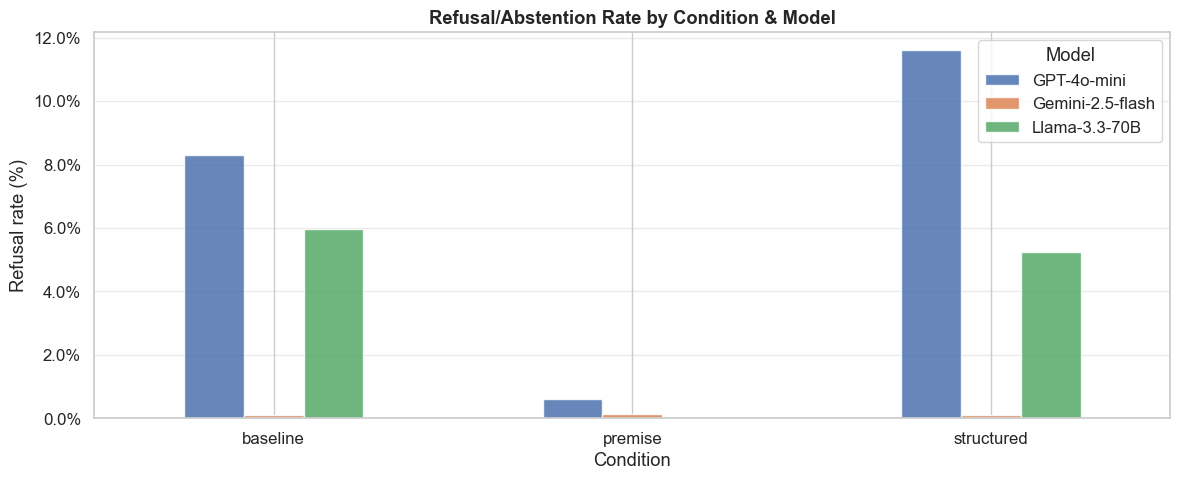

Refusal rate (%) by task × condition (all models pooled):
condition            baseline  premise  structured
task                                              
affirm_reverse            0.0      NaN         0.0
case_existence            0.0      NaN         0.0
citation_retrieval        0.2      NaN         0.8
cited_precedent           0.1      NaN         0.7
court_id                  0.0      NaN         0.0
fake_case_existence       0.0      0.0         0.0
fake_dissent              2.7      0.7         0.7
fake_year_overruled       0.0      0.0         0.0
majority_author          37.0      NaN        37.0
quotation                38.6      NaN        52.9
year_overruled            0.0      NaN         0.0


In [11]:
# Dahl et al. use -99 to encode refusals
df['refusal'] = df['correctness_score'] == -99

refusal_rates = (
    df.groupby(['task','model_label','condition'])['refusal']
    .mean().mul(100).unstack('condition').round(2)
)

fig, ax = plt.subplots(figsize=(12, 5))
refusal_by_cond = df.groupby(['condition','model_label'])['refusal'].mean().mul(100).unstack()
refusal_by_cond.plot(kind='bar', ax=ax, alpha=0.85, edgecolor='white')
ax.set_xlabel('Condition')
ax.set_ylabel('Refusal rate (%)')
ax.set_title('Refusal/Abstention Rate by Condition & Model', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Model')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('results/fig_refusal.png', dpi=150, bbox_inches='tight')
plt.show()

print('Refusal rate (%) by task × condition (all models pooled):')
print(df.groupby(['task','condition'])['refusal'].mean().mul(100).unstack().round(2))

## 9. Latency Analysis

Median latency (s):
condition         baseline  premise  structured
model_label                                    
GPT-4o-mini            0.7      0.9         0.7
Gemini-2.5-flash       1.8      2.5         1.8
Llama-3.3-70B          0.2      0.2         0.2


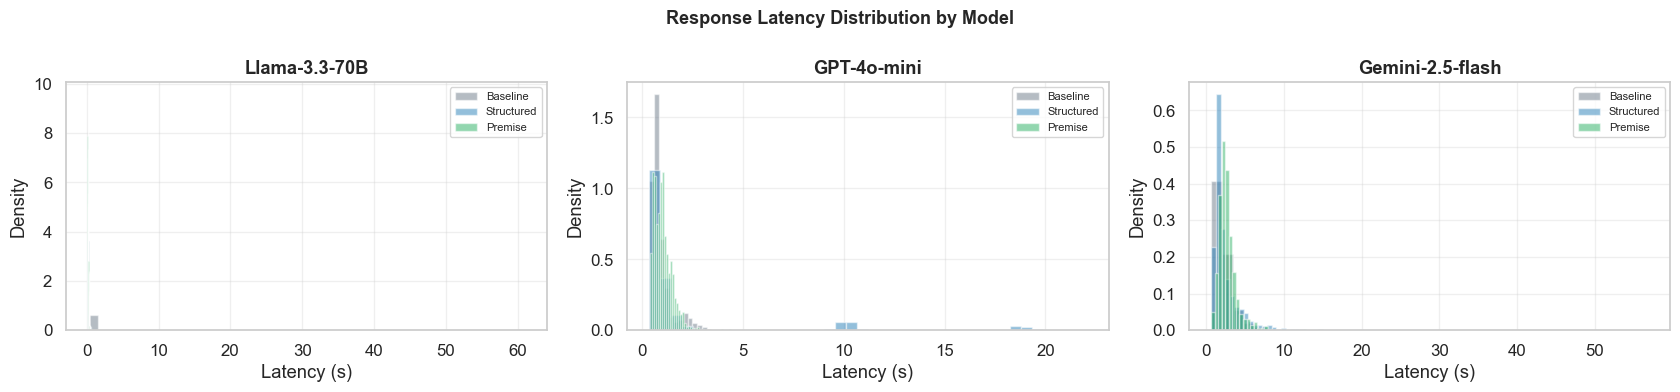

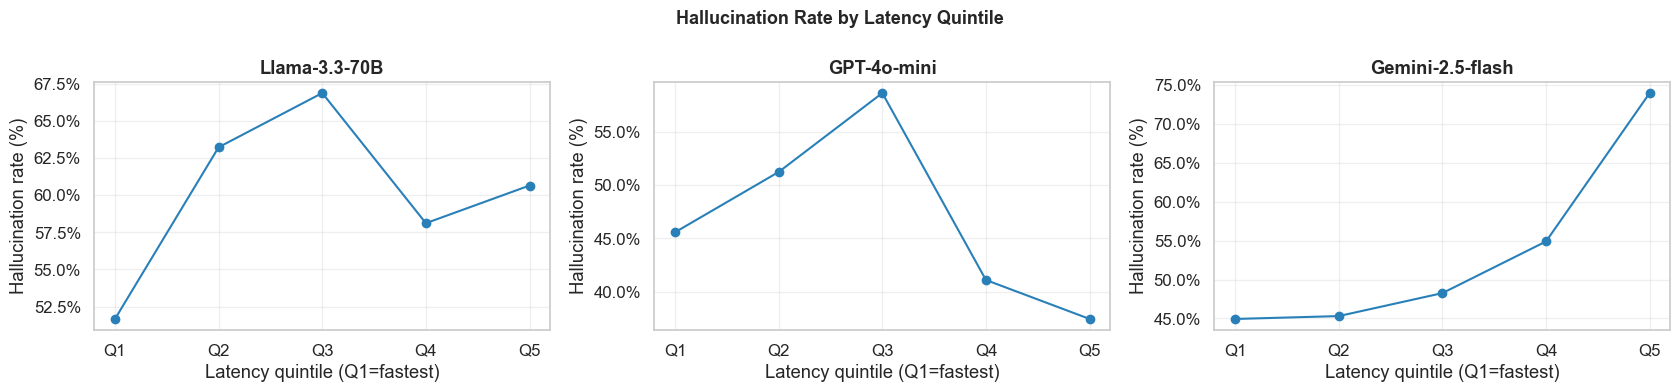

In [12]:
lat = df[df['latency_s'].notna() & (df['latency_s'] > 0) & (df['latency_s'] < 120)]

# Median latency by model × condition
lat_summary = lat.groupby(['model_label','condition'])['latency_s'].median().unstack()
print('Median latency (s):')
print(lat_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
for ax, model in zip(axes, models):
    sub = lat[lat['model_label'] == model]
    for cond in ['baseline','structured','premise']:
        c = sub[sub['condition'] == cond]['latency_s']
        if len(c):
            ax.hist(c, bins=40, alpha=0.5, label=cond.title(), color=PALETTE[cond], density=True)
    ax.set_title(model, fontweight='bold')
    ax.set_xlabel('Latency (s)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Response Latency Distribution by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/fig_latency.png', dpi=150, bbox_inches='tight')
plt.show()

# Latency vs hallucination — do slower responses hallucinate less?
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, model in zip(axes, models):
    sub = lat[lat['model_label'] == model]
    bins = pd.qcut(sub['latency_s'], q=5, duplicates='drop')
    hall_by_lat = sub.groupby(bins, observed=True)['hallucination'].mean().mul(100)
    ax.plot(range(len(hall_by_lat)), hall_by_lat.values, marker='o', color=PALETTE['structured'])
    ax.set_xticks(range(len(hall_by_lat)))
    ax.set_xticklabels([f'Q{i+1}' for i in range(len(hall_by_lat))])
    ax.set_xlabel('Latency quintile (Q1=fastest)')
    ax.set_ylabel('Hallucination rate (%)')
    ax.set_title(model, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(alpha=0.3)
fig.suptitle('Hallucination Rate by Latency Quintile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/fig_latency_hall.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Year Era Analysis (decade bins)

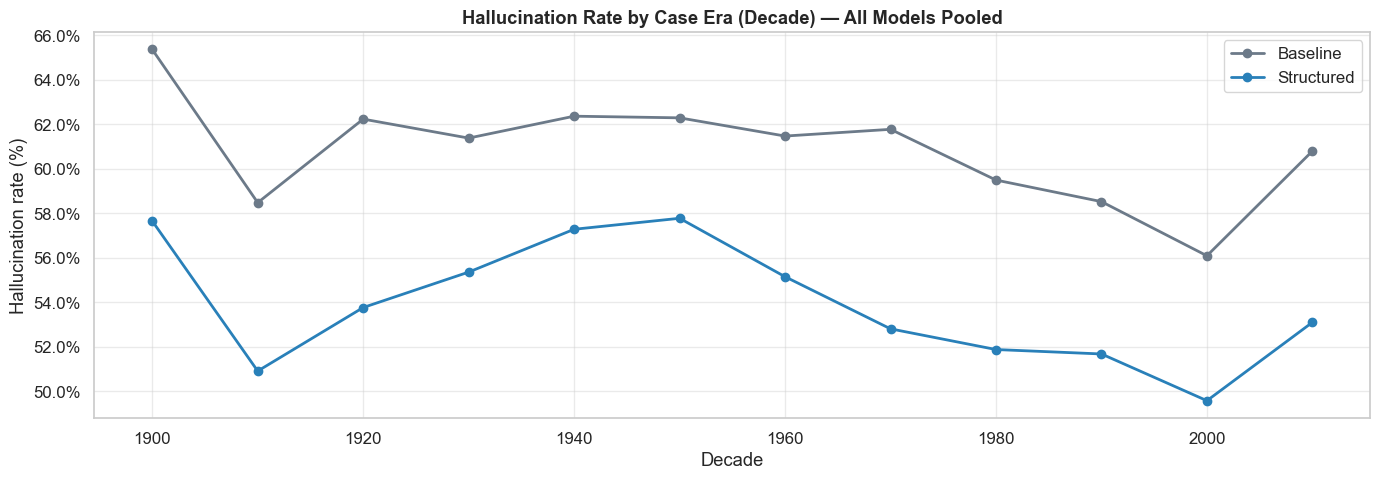

Decade coverage:
decade
1900    1246
1910    1239
1920    1417
1930    1977
1940    1886
1950    2401
1960    1934
1970    2085
1980    2252
1990    2388
2000    1958
2010    1939
Name: n_rows, dtype: int64


In [13]:
yr = df[df['year'].notna() & (df['year'] >= 1900) & (df['year'] <= 2024)].copy()
yr['decade'] = (yr['year'] // 10 * 10).astype(int)

decade_rates = (
    yr.groupby(['decade','condition'])['hallucination']
    .mean().mul(100).unstack('condition')
)

fig, ax = plt.subplots(figsize=(14, 5))
for cond in ['baseline','structured']:
    if cond in decade_rates.columns:
        ax.plot(decade_rates.index, decade_rates[cond], marker='o',
                label=cond.title(), color=PALETTE[cond], linewidth=2)
ax.set_xlabel('Decade')
ax.set_ylabel('Hallucination rate (%)')
ax.set_title('Hallucination Rate by Case Era (Decade) — All Models Pooled', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('results/fig_year_era.png', dpi=150, bbox_inches='tight')
plt.show()

print('Decade coverage:')
print(yr.groupby('decade').size().rename('n_rows'))

## 11. Fake vs Real Cases

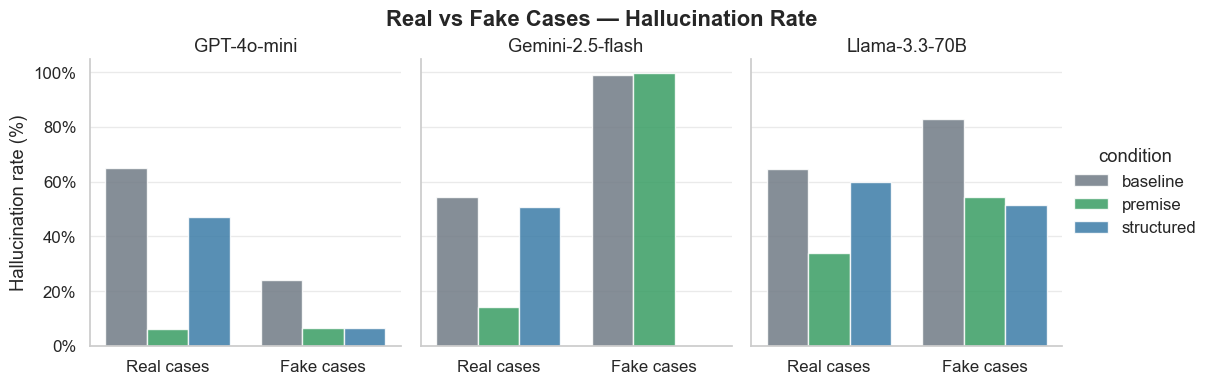

In [14]:
df['is_fake'] = df['case_source'].eq('fake')

fake_rates = (
    df.groupby(['is_fake','model_label','condition'])['hallucination']
    .mean().mul(100).reset_index()
)
fake_rates['group'] = fake_rates['is_fake'].map({True: 'Fake cases', False: 'Real cases'})

g = sns.catplot(
    data=fake_rates, kind='bar',
    x='group', y='hallucination', hue='condition',
    col='model_label', palette=PALETTE,
    height=4, aspect=0.9, alpha=0.85
)
g.set_axis_labels('', 'Hallucination rate (%)')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis='y', alpha=0.4)
g.fig.suptitle('Real vs Fake Cases — Hallucination Rate', fontweight='bold', y=1.02)
g.fig.savefig('results/fig_fake_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Best & Worst Performing Combinations

In [15]:
combos = (
    df.groupby(['task','model_label','condition'])['hallucination']
    .agg(['mean','count']).reset_index()
)
combos['mean'] = combos['mean'] * 100
combos = combos[combos['count'] >= 50]  # min sample size
combos = combos.sort_values('mean')

print('TOP 10 best (lowest hallucination):')
print(combos.head(10)[['task','model_label','condition','mean','count']].to_string(index=False))

print('\nTOP 10 worst (highest hallucination):')
print(combos.tail(10)[['task','model_label','condition','mean','count']].to_string(index=False))

TOP 10 best (lowest hallucination):
               task      model_label  condition  mean  count
       fake_dissent    Llama-3.3-70B    premise   0.6    500
fake_year_overruled      GPT-4o-mini    premise   0.8    500
       fake_dissent    Llama-3.3-70B structured   0.8    500
fake_year_overruled      GPT-4o-mini structured   0.8    500
     case_existence Gemini-2.5-flash   baseline   4.1    777
     case_existence Gemini-2.5-flash structured   5.4    499
fake_year_overruled Gemini-2.5-flash    premise   5.8    500
fake_case_existence      GPT-4o-mini    premise   6.6    500
fake_case_existence      GPT-4o-mini structured   6.6    500
     case_existence    Llama-3.3-70B structured   7.0    500

TOP 10 worst (highest hallucination):
               task      model_label  condition  mean  count
     year_overruled      GPT-4o-mini structured  89.8    500
fake_year_overruled    Llama-3.3-70B   baseline  92.2    500
    cited_precedent      GPT-4o-mini structured  97.4    500
fake_case_

## 13. Model Agreement — Do Models Hallucinate on the Same Rows?

Across rows seen by all 3 models (baseline):
  All hallucinate:   38.1%
  None hallucinate:  23.5%
  Disagreement:      38.4%

Agreement by task:
                     all_hallucinate  none_hallucinate  disagreement
task                                                                
affirm_reverse                  12.2              18.6          69.2
case_existence                   0.2              71.6          28.2
citation_retrieval              63.2               5.0          31.8
cited_precedent                 99.0               0.0           1.0
court_id                        28.0              41.6          30.4
fake_case_existence             23.7               0.0          76.3


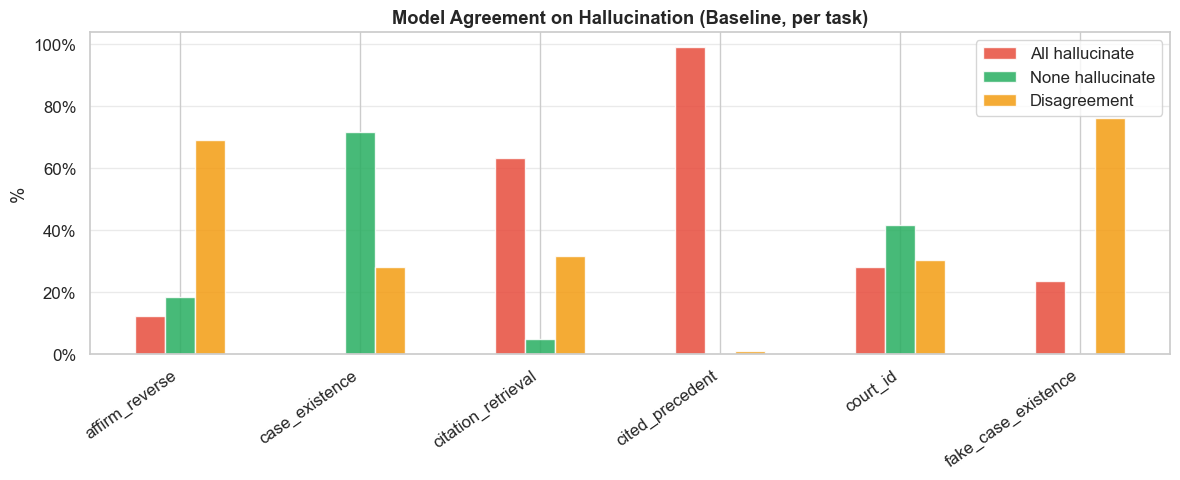

In [16]:
# For baseline condition, which row_ids do all 3 models hallucinate on?
base_df = df[df['condition'] == 'baseline'][['row_id','task','model_key','hallucination']]
wide = base_df.pivot_table(index=['row_id','task'], columns='model_key', values='hallucination')
wide.columns.name = None
wide = wide.dropna()  # rows covered by all 3 models

if set(['groq','gpt4omini','gemini']).issubset(wide.columns):
    wide['all_hallucinate'] = wide[['groq','gpt4omini','gemini']].all(axis=1)
    wide['none_hallucinate'] = ~wide[['groq','gpt4omini','gemini']].any(axis=1)
    wide['disagreement'] = ~(wide['all_hallucinate'] | wide['none_hallucinate'])
    
    print('Across rows seen by all 3 models (baseline):')
    print(f"  All hallucinate:   {wide['all_hallucinate'].mean()*100:.1f}%")
    print(f"  None hallucinate:  {wide['none_hallucinate'].mean()*100:.1f}%")
    print(f"  Disagreement:      {wide['disagreement'].mean()*100:.1f}%")
    
    # By task
    task_agree = wide.reset_index().groupby('task')[['all_hallucinate','none_hallucinate','disagreement']].mean().mul(100).round(1)
    print('\nAgreement by task:')
    print(task_agree.to_string())

    fig, ax = plt.subplots(figsize=(12, 5))
    task_agree[['all_hallucinate','none_hallucinate','disagreement']].rename(columns={
        'all_hallucinate': 'All hallucinate',
        'none_hallucinate': 'None hallucinate',
        'disagreement': 'Disagreement'
    }).plot(kind='bar', ax=ax, alpha=0.85, color=['#E74C3C','#27AE60','#F39C12'])
    ax.set_xlabel('')
    ax.set_ylabel('%')
    ax.set_title('Model Agreement on Hallucination (Baseline, per task)', fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.savefig('results/fig_model_agreement.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not all 3 models present in baseline data — skipping agreement analysis.')
    print('Available model keys:', wide.columns.tolist())

HERE: adopt this, do only for binary. 

## 14. Task × Court Level Interaction Heatmap

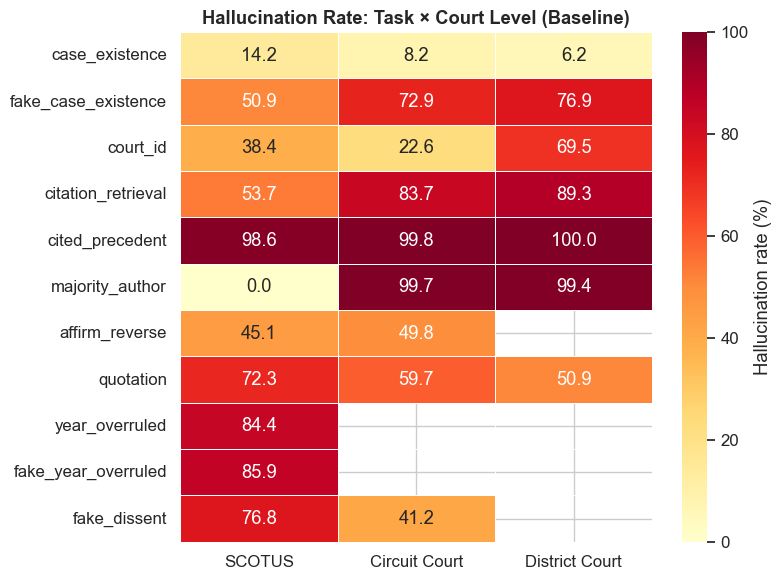

In [17]:
tc = (
    df[df['condition'] == 'baseline']
    .groupby(['task','court_label'])['hallucination']
    .mean().mul(100).unstack('court_label')
)
tc = tc.reindex([t for t in TASK_ORDER if t in tc.index])
tc = tc[[c for c in ['SCOTUS','Circuit Court','District Court'] if c in tc.columns]]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(tc, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Hallucination rate (%)'})
ax.set_title('Hallucination Rate: Task × Court Level (Baseline)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('results/fig_task_court_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Summary: Strongest Wins & Key Findings

In [18]:
# Compute % improvement per model × task for structured vs baseline
rates = df.groupby(['task','model_label','condition'])['hallucination'].mean().mul(100)
base_s = rates.xs('baseline', level='condition')
struct_s = rates.xs('structured', level='condition')
delta_s = (struct_s - base_s).reset_index()
delta_s.columns = ['task','model','delta_struct']

print('=== SUMMARY TABLE: Δ Hallucination (Structured - Baseline, pp) ===')
print(delta_s.pivot(index='task', columns='model', values='delta_struct').round(1).to_string())

print('\n=== KEY FINDINGS ===')
print(f"Biggest win:  {delta_s.loc[delta_s['delta_struct'].idxmin(), 'task']} / "
      f"{delta_s.loc[delta_s['delta_struct'].idxmin(), 'model']} "
      f"({delta_s['delta_struct'].min():.1f} pp)")
print(f"Biggest harm: {delta_s.loc[delta_s['delta_struct'].idxmax(), 'task']} / "
      f"{delta_s.loc[delta_s['delta_struct'].idxmax(), 'model']} "
      f"(+{delta_s['delta_struct'].max():.1f} pp)")

# Overall by model
overall = df.groupby(['model_label','condition'])['hallucination'].mean().mul(100).unstack()
overall['Δ struct'] = overall.get('structured', np.nan) - overall.get('baseline', np.nan)
print('\n=== OVERALL RATES ===')
print(overall.round(1).to_string())

=== SUMMARY TABLE: Δ Hallucination (Structured - Baseline, pp) ===
model                GPT-4o-mini  Gemini-2.5-flash  Llama-3.3-70B
task                                                             
affirm_reverse              -4.8               0.0            5.0
case_existence              -7.4               1.3           -1.6
citation_retrieval          -1.4              -1.4           -0.6
cited_precedent             -2.0               0.6            0.0
court_id                     0.2               0.9           18.8
fake_case_existence        -17.4               NaN          -31.4
fake_dissent               -56.4               NaN          -47.6
fake_year_overruled        -78.8               NaN          -25.4
majority_author              0.0               NaN            0.0
quotation                  -30.8               NaN            2.2
year_overruled               4.2               NaN            3.0

=== KEY FINDINGS ===
Biggest win:  fake_year_overruled / GPT-4o-mini (-78.

HERE: I stil lhave a lot of NaNs for Gemini. Why 